In [1]:
import zipfile
import os

# --- PARAMÈTRES ---
# Chemin vers le dataset uploadé dans l'environnement Colab
dataset_zip_path = 'data.zip'
extract_dir = 'dataset/'

print("=== Phase 1 : Vérification et Extraction du Dataset ===")

try:
    with zipfile.ZipFile(dataset_zip_path, 'r') as z:
        total_files = len(z.namelist())
        print(f"[INFO] Archive lue avec succès. Contient {total_files} fichiers.")

        # Contrôle qualité : aperçu de la structure
        print("[INFO] Aperçu des premiers fichiers de l'archive :")
        for i, name in enumerate(z.namelist()[:10]):
            print(f"  ├── {name}")

        # Extraction des données pour le traitement Pandas/NumPy
        z.extractall(extract_dir)
        print(f"\n[INFO] Extraction terminée dans le dossier : ./{extract_dir}")

except FileNotFoundError:
    print(f"[ERREUR] Le fichier '{dataset_zip_path}' est introuvable.")
    print("-> Action requise : Veuillez glisser-déposer votre fichier data.zip dans le panneau de gauche de Colab.")
except zipfile.BadZipFile:
    print(f"[ERREUR] Le fichier '{dataset_zip_path}' est corrompu ou n'est pas un ZIP valide.")

=== Phase 1 : Vérification et Extraction du Dataset ===
[INFO] Archive lue avec succès. Contient 124 fichiers.
[INFO] Aperçu des premiers fichiers de l'archive :
  ├── data/dataset_BRUIT/
  ├── data/dataset_L/
  ├── data/dataset_O/
  ├── data/dataset_Z/
  ├── data/dataset_BRUIT/BRUIT_001.csv
  ├── data/dataset_BRUIT/BRUIT_002.csv
  ├── data/dataset_BRUIT/BRUIT_003.csv
  ├── data/dataset_BRUIT/BRUIT_004.csv
  ├── data/dataset_BRUIT/BRUIT_005.csv
  ├── data/dataset_BRUIT/BRUIT_006.csv

[INFO] Extraction terminée dans le dossier : ./dataset/


In [6]:
import os
import pandas as pd
import numpy as np

# Adapte le chemin selon l'endroit où sont tes dossiers
base_path = '/content/dataset/data'

classes_folders = ['dataset_BRUIT', 'dataset_L', 'dataset_O', 'dataset_Z']

data = []
labels = []

print("📊 Début du chargement des classes...")

for index, folder in enumerate(classes_folders):
    folder_path = os.path.join(base_path, folder)

    if not os.path.exists(folder_path):
        continue

    files = [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')]
    print(f"  -> {folder} : {len(files)} fichiers trouvés.")

    compteur_valides = 0
    for f in files:
        file_path = os.path.join(folder_path, f)
        try:
            # Lecture du fichier
            df = pd.read_csv(file_path)

            # Nettoyage : On supprime les lignes vides éventuelles créées par l'UART
            df = df.dropna()

            # TOLÉRANCE : Si on a au moins 100 points, on valide !
            if len(df) >= 100:
                # On coupe strictement aux 100 premiers points pour l'IA
                df_100 = df.head(100)

                sample = df_100[['ax', 'ay', 'az']].values
                sample_normalized = sample / 2.0  # Normalisation

                data.append(sample_normalized)
                labels.append(index)
                compteur_valides += 1
            else:
                print(f"   ⚠️ Fichier ignoré : {f} est trop court ({len(df)} lignes au lieu de 100).")

        except Exception as e:
            print(f"   ❌ Erreur sur {f}: {e}")

X = np.array(data)
y = np.array(labels)

print("\n✅ ÉTAPE 2 RÉUSSIE !")
print(f"Matrice X : {X.shape} (Nombre d'exemples, Points, Axes)")
print(f"Matrice y : {y.shape} (Labels correspondants)")

📊 Début du chargement des classes...
  -> dataset_BRUIT : 30 fichiers trouvés.
  -> dataset_L : 30 fichiers trouvés.
  -> dataset_O : 30 fichiers trouvés.
  -> dataset_Z : 30 fichiers trouvés.

✅ ÉTAPE 2 RÉUSSIE !
Matrice X : (120, 100, 3) (Nombre d'exemples, Points, Axes)
Matrice y : (120,) (Labels correspondants)


[INFO] Application de la Data Augmentation...
[INFO] Dataset final : 384 échantillons d'entraînement, 96 de validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



[INFO] Lancement de l'entraînement (80 époques)...

=== RÉSULTATS DE CONVERGENCE ===
 -> Précision Entraînement : 98.44%
 -> Précision Validation   : 95.83%


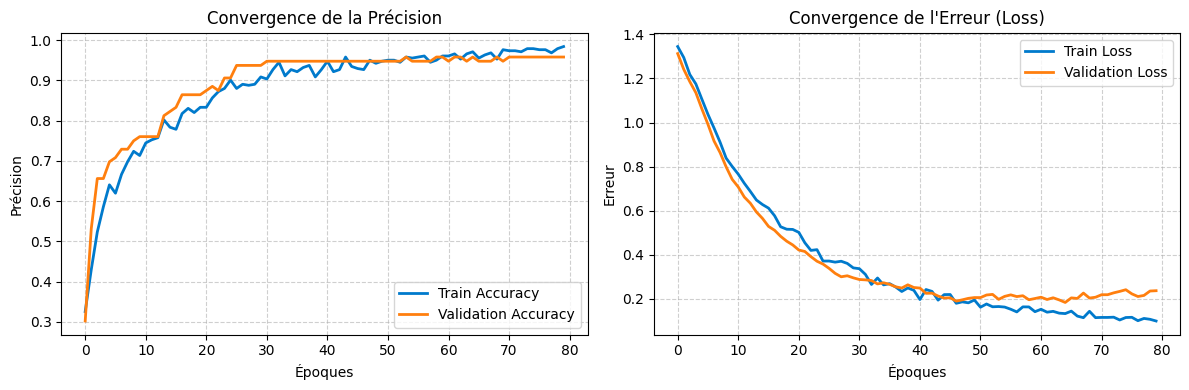

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import numpy as np

# --- 1. DATA AUGMENTATION (Jittering) ---
def augment_dataset(X_data, y_data, noise_factor=0.015, augment_factor=3):
    """
    Augmente artificiellement la taille du dataset en injectant un bruit gaussien
    pour simuler l'imprécision du capteur physique et les tremblements de la main.
    """
    X_aug, y_aug = [], []
    for i in range(len(X_data)):
        # Conservation de la donnée originale
        X_aug.append(X_data[i])
        y_aug.append(y_data[i])

        # Génération des variantes bruitées
        for _ in range(augment_factor):
            noise = np.random.normal(0, noise_factor, X_data[i].shape)
            X_aug.append(X_data[i] + noise)
            y_aug.append(y_data[i])

    return np.array(X_aug), np.array(y_aug)

print("[INFO] Application de la Data Augmentation...")
# IMPORTANT : On utilise 'X' directement car la normalisation a déjà été faite à l'acquisition
X_final, y_final = augment_dataset(X, y)

# Séparation Train/Validation (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)
print(f"[INFO] Dataset final : {len(X_train)} échantillons d'entraînement, {len(X_test)} de validation.")

# --- 2. ARCHITECTURE DU MODÈLE (TinyML) ---
# Topologie MLP 16 -> 8 validée pour une empreinte Flash < 6 Ko
model = models.Sequential([
    layers.InputLayer(input_shape=(100, 3)),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),                 # Régularisation contre l'overfitting
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='softmax') # 4 classes : BRUIT, L, O, Z
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# --- 3. ENTRAÎNEMENT ---
print("\n[INFO] Lancement de l'entraînement (80 époques)...")
history = model.fit(X_train, y_train, epochs=80, validation_data=(X_test, y_test), verbose=0)

# --- 4. ANALYSE DES PERFORMANCES ---
final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100

print("\n=== RÉSULTATS DE CONVERGENCE ===")
print(f" -> Précision Entraînement : {final_train_acc:.2f}%")
print(f" -> Précision Validation   : {final_val_acc:.2f}%")

# Affichage professionnel des courbes
plt.figure(figsize=(12, 4))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#007acc', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
plt.title('Convergence de la Précision')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#007acc', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Convergence de l\'Erreur (Loss)')
plt.xlabel('Époques')
plt.ylabel('Erreur')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf
import os

print("\n[INFO] Lancement de la quantification Post-Entraînement (PTQ)...")

# --- 1. CONVERSION & QUANTIFICATION ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimisation par défaut : quantification dynamique (Dynamic Range Quantization)
# Convertit les poids de Float32 vers INT8 pour diviser la taille par 4.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model_quant = converter.convert()

# --- 2. SAUVEGARDE DU MODÈLE COMPRESSÉ ---
model_filename = 'gesture_model_quantized.tflite'

with open(model_filename, 'wb') as f:
    f.write(tflite_model_quant)

# --- 3. AUDIT MÉMOIRE ---
taille_octets = os.path.getsize(model_filename)
taille_ko = taille_octets / 1024.0

print("\n=== RAPPORT DE COMPRESSION ===")
print(f" -> Nombre de paramètres : {model.count_params()}")
print(f" -> Empreinte disque     : {taille_ko:.2f} Ko")

# Vérification par rapport au budget mémoire (Target < 10 Ko)
if taille_ko < 10.0:
    print("[SUCCÈS] Le modèle respecte le budget mémoire alloué.")
    print(f"[INFO] Fichier '{model_filename}' prêt pour la compilation C via X-CUBE-AI.")
else:
    print("[AVERTISSEMENT] Le modèle dépasse le budget mémoire. Risque d'échec sur STM32.")


[INFO] Lancement de la quantification Post-Entraînement (PTQ)...
Saved artifact at '/tmp/tmp183dyn05'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137073334797328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073334799824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073334798480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073334798096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073334799248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073334800208: TensorSpec(shape=(), dtype=tf.resource, name=None)

=== RAPPORT DE COMPRESSION ===
 -> Nombre de paramètres : 4988
 -> Empreinte disque     : 8.61 Ko
[SUCCÈS] Le modèle respecte le budget mémoire alloué.
[INFO] Fichier 'gesture_model_quantized.tflite' prêt pour la compilation C via X-C